# Homework 1

This file contains the solutions to the computational problems in Homework 1 from MATH 5750 taught by Braxton Osting during the Fall 2026 semester.

Import necessary packages, load dataset, and set random seed

In [10]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import math

pd.set_option("display.precision", 3)

In [2]:
df = load_diabetes(as_frame=True, scaled=False).frame

SEED = 0
np.random.seed(SEED)

Define train/test split

In [3]:
X = df.drop(columns='target').values
y = df.target.values
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size=100, random_state=SEED)

(a) First we want to analyze the shape of the dataset and create two figures

In [4]:
print(df.shape)
df.head()

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.860,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.892,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.673,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.890,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.290,80.0,135.0


Confirm that there are no missing values.

In [5]:
df.isna().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Describe the dataset using multiple characteristics

In [6]:
df[["bmi","target","bp"]].describe()

,bmi,target,bp
count,442.000,442.000,442.000
mean,26.376,152.133,94.647
std,4.418,77.093,13.831
min,18.000,25.000,62.000
25%,23.200,87.000,84.000
50%,25.700,140.500,93.000
75%,29.275,211.500,105.000
max,42.200,346.000,133.000


In [7]:
df[["bmi","target","bp"]].corr()

,bmi,target,bp
bmi,1.000,0.586,0.395
target,0.586,1.000,0.441
bp,0.395,0.441,1.000


Make a histogram and scatter plot as directed

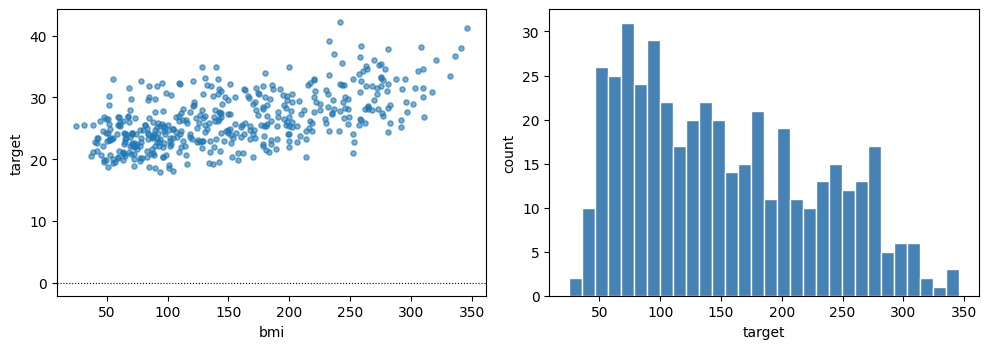

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].scatter(df.target, df.bmi, s=14, alpha=0.6)
ax[0].axhline(0, color="k", lw=0.8, ls=":")
ax[0].set_xlabel("bmi"); ax[0].set_ylabel("target")
ax[1].hist(df.target, bins=30, color="steelblue", edgecolor="w")
ax[1].set_xlabel("target"); ax[1].set_ylabel("count")
plt.tight_layout(); plt.show()

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import math

results = []

for d in [1, 2, 3]:
    model = make_pipeline(
        PolynomialFeatures(degree=d),
        StandardScaler(),
        LinearRegression()
    )
    model.fit(Xtr, ytr)
    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)
    p = math.comb(Xtr.shape[1] + d, d)
    results.append({
        "degree": d,
        "p": p,
        "training_MSE": mean_squared_error(ytr, train_pred),
        "test_MSE": mean_squared_error(yte, test_pred)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 degree   p  training_MSE  test_MSE
      1  11     2.429e+03  3170.184
      2  66     7.733e+02 22440.791
      3 286     7.301e-24 36205.294


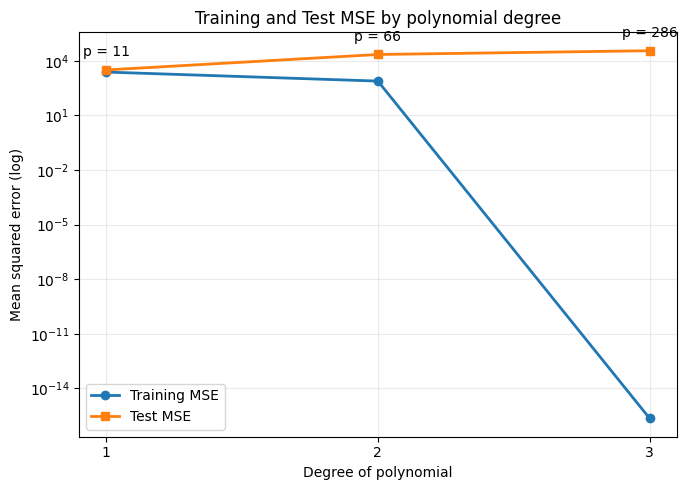

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

degrees = results_df["degree"].to_numpy()
train_mse = results_df["training_MSE"].to_numpy()
test_mse = results_df["test_MSE"].to_numpy()

# A computed zero may be around 1e-30 because of floating-point arithmetic.
plot_floor = np.finfo(float).eps

ax.plot(
    degrees,
    np.maximum(train_mse, plot_floor),
    marker="o",
    linewidth=2,
    label="Training MSE"
)

ax.plot(
    degrees,
    np.maximum(test_mse, plot_floor),
    marker="s",
    linewidth=2,
    label="Test MSE"
)

for d, p, train_err, test_err in zip(
    degrees, results_df["p"], train_mse, test_mse
):
    ax.annotate(
        f"p = {p}",
        (d, max(train_err, test_err, plot_floor)),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

ax.set_xticks([1, 2, 3])
ax.set_xlabel("Degree of polynomial")
ax.set_ylabel("Mean squared error (log)")
ax.set_yscale("log")
ax.set_title("Training and Test MSE by polynomial degree")
ax.grid(True, which="both", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()